In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap, os, warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score

%matplotlib inline
warnings.filterwarnings('ignore')

# Create output folders
for folder in ['../png/explore', '../png/personas', '../png/shap', '../png/fairness', '../png/strategy']:
    os.makedirs(folder, exist_ok=True)

# Load + clean
df = pd.read_csv('../data/raw/bank-additional/bank-additional-full.csv', sep=';')
df['y'] = df['y'].map({'yes': 1, 'no': 0}).astype(int)
if 'duration' in df.columns: df.drop(columns=['duration'], inplace=True)  # remove leakage
df['was_contacted'] = np.where(df['pdays'] == 999, 0, 1)                  # 999 = never called
df.drop(columns=['pdays'], inplace=True)

print(f"Records: {len(df):,} | Features: {df.shape[1]} | Conversion: {df['y'].mean():.1%}")

c:\Users\marie\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Records: 41,188 | Features: 20 | Conversion: 11.3%


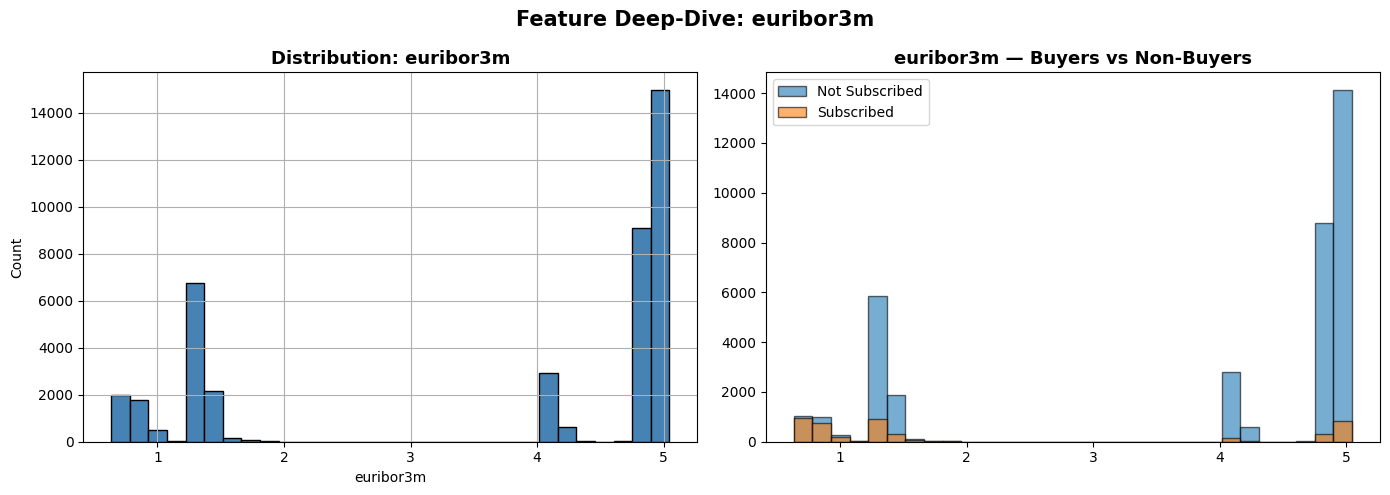

Saved → ../png/explore/euribor3m_explore.png


In [5]:
# CELL 2 — EXPLORE ANY COLUMN
# ── Change colum ──
column = 'euribor3m'   # try: age, job, campaign, marital, education
# ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if df[column].dtype in ['int64', 'float64']:
    # Numeric: histogram + boxplot
    df[column].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='black')
    axes[0].set_title(f'Distribution: {column}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel(column); axes[0].set_ylabel('Count')

    # Side-by-side: buyers vs non-buyers
    for label, grp in df.groupby('y')[column]:
        axes[1].hist(grp, bins=30, alpha=0.6,
                     label='Subscribed' if label == 1 else 'Not Subscribed',
                     edgecolor='black')
    axes[1].set_title(f'{column} — Buyers vs Non-Buyers', fontsize=13, fontweight='bold')
    axes[1].legend()
else:
    # Categorical: counts + conversion rate
    df[column].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(f'Count: {column}', fontsize=13, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)

    # Red line = overall average
    conv = df.groupby(column)['y'].mean().sort_values()
    conv.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
    axes[1].axhline(y=df['y'].mean(), color='red', linestyle='--', linewidth=2, label='Avg')
    axes[1].set_title(f'Conversion Rate: {column}', fontsize=13, fontweight='bold')
    axes[1].legend(); axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(f'Feature Deep-Dive: {column}', fontsize=15, fontweight='bold')
plt.tight_layout()
path = f'../png/explore/{column}_explore.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

Optimal K chosen: 2


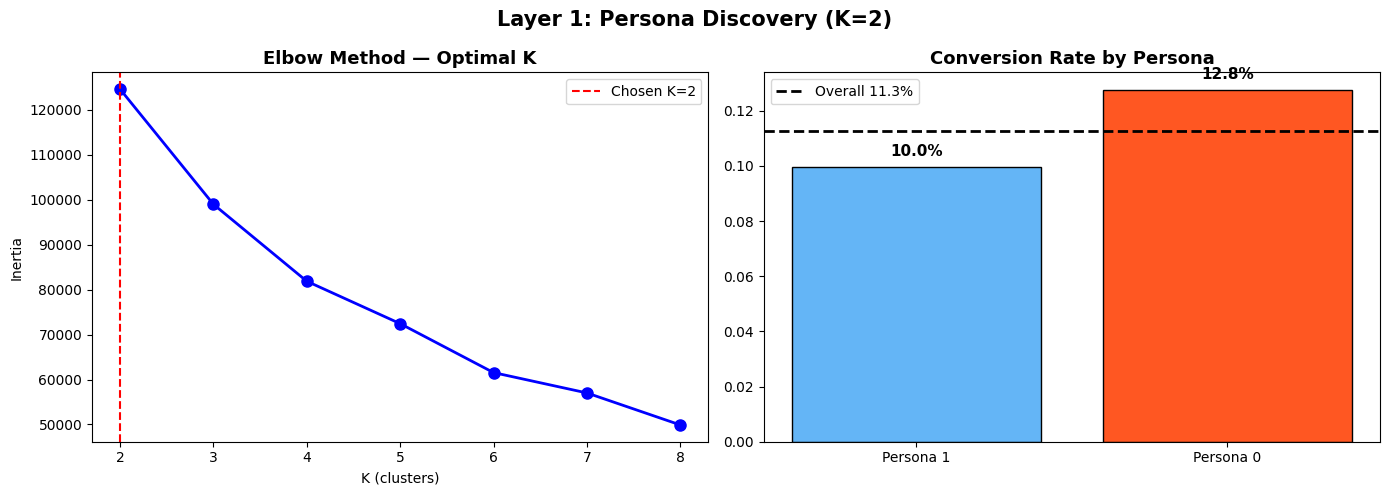

Saved → ../png/personas/persona_clusters.png

Persona breakdown:
  Persona 0: n=19,259 | avg_age=33 | conv=12.8%
  Persona 1: n=21,929 | avg_age=46 | conv=10.0%


In [7]:
# CELL 3 — PERSONA CLUSTERS
# ── Change this ──
n_clusters = 4   # try 3–6
# ── Add this section to determine optimal K ──
inertias = [KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_scaled).inertia_ for k in range(2, 9)]
optimal_k = np.argmin(np.diff(inertias)) + 2  # Optimal K based on inertia change
print(f"Optimal K chosen: {optimal_k}")
n_clusters = optimal_k  # Update cluster number

# Encode demographics only
micro = df[['age', 'job', 'marital', 'education']].copy()
for col in micro.select_dtypes('object'):
    micro[col] = LabelEncoder().fit_transform(micro[col].astype(str))

# Scale → cluster
X_scaled = StandardScaler().fit_transform(micro)
km = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
df['Persona'] = km.fit_predict(X_scaled)

# ── ELBOW: find optimal K ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(2, 9), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=n_clusters, color='red', linestyle='--', label=f'Chosen K={n_clusters}')
axes[0].set_title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K (clusters)'); axes[0].set_ylabel('Inertia'); axes[0].legend()

# ── Conversion rate by persona ────────────────────────────────────────────
conv = df.groupby('Persona')['y'].mean().sort_values()
colors = ['#FF5722' if v > df['y'].mean() else '#64B5F6' for v in conv]
bars = axes[1].bar(range(len(conv)), conv.values, color=colors, edgecolor='black')
axes[1].axhline(df['y'].mean(), color='black', linestyle='--', linewidth=2, label=f'Overall {df["y"].mean():.1%}')
axes[1].set_xticks(range(len(conv)))
axes[1].set_xticklabels([f'Persona {i}' for i in conv.index])
axes[1].set_title('Conversion Rate by Persona', fontsize=13, fontweight='bold')
axes[1].legend()

# Value labels on bars
for bar, val in zip(bars, conv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.004,
                 f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle(f'Layer 1: Persona Discovery (K={n_clusters})', fontsize=15, fontweight='bold')
plt.tight_layout()
path = '../png/personas/persona_clusters.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

# Cluster summary
print(f"\nPersona breakdown:")
for p in range(n_clusters):
    sub = df[df['Persona'] == p]
    print(f"  Persona {p}: n={len(sub):,} | avg_age={sub['age'].mean():.0f} | conv={sub['y'].mean():.1%}")

Scenario: euribor3m > 3.0 | n=27,690 | conv=4.8%
AUC: 0.7649


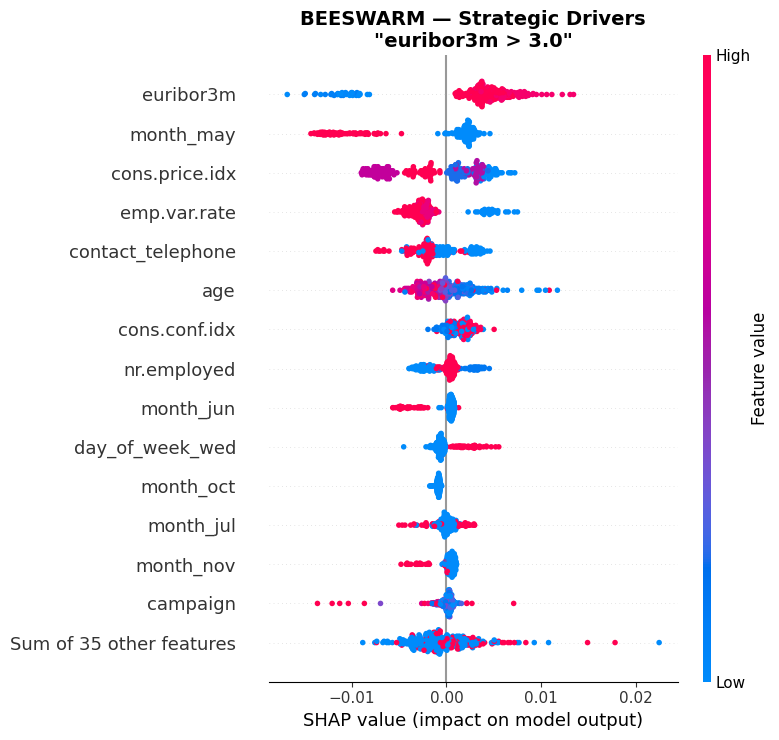

Saved → ../png/shap/euribor3m_gt_3.0_beeswarm.png


In [24]:
# CELL 4A — SHAP BEESWARM
# ── Change this ──
#filter_expr = None             # Global baseline
filter_expr = 'euribor3m > 3.0'   # High rates
# filter_expr = 'euribor3m < 1.5'   # Low rates
# filter_expr = "job == 'retired'"  # Retirees
# filter_expr = "job == 'student'"  # Students
# filter_expr = 'age < 35'          # Young market
# filter_expr = 'age > 55'          # Senior market
# filter_expr = 'campaign == 1'     # First touch
# filter_expr = 'campaign > 3'      # Contact fatigue
# filter_expr = 'was_contacted == 1' # Warm leads
# filter_expr = 'was_contacted == 0' # Cold prospects
# ─────────────────

# Filter + encode
work = df.query(filter_expr).copy() if filter_expr else df.copy()
scenario = filter_expr or 'Global Baseline'
print(f"Scenario: {scenario} | n={len(work):,} | conv={work['y'].mean():.1%}")

X = pd.get_dummies(work.drop(['y', 'Persona'], axis=1), drop_first=True)
y = work['y']

# Train model
model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
model.fit(X, y)
auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
print(f"AUC: {auc:.4f}")

# SHAP values (Class 1 = subscribed)
X_sample = X.sample(min(300, len(X)), random_state=42)
explainer = shap.TreeExplainer(model)
raw = explainer.shap_values(X_sample)              # shape: (n, features, 2)
shap_matrix = raw[:, :, 1] if raw.ndim == 3 else raw[1]  # keep "yes" class
ev = explainer.expected_value
base = ev[1] if isinstance(ev, (list, np.ndarray)) else ev

sv = shap.Explanation(values=shap_matrix, base_values=np.full(len(X_sample), base),
                       data=X_sample.values, feature_names=X_sample.columns.tolist())

# ── BEESWARM — Strategy Map ────────────────────────────────────────────────
# Each dot = one customer
plt.figure(figsize=(11, 8))
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title(f'BEESWARM — Strategic Drivers\n"{scenario}"',
          fontsize=14, fontweight='bold')
plt.tight_layout()
sname = (filter_expr or 'Global').replace(' ', '_').replace("'", '').replace('>', 'gt').replace('<', 'lt').replace('==', 'eq')
path = f'../png/shap/{sname}_beeswarm.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

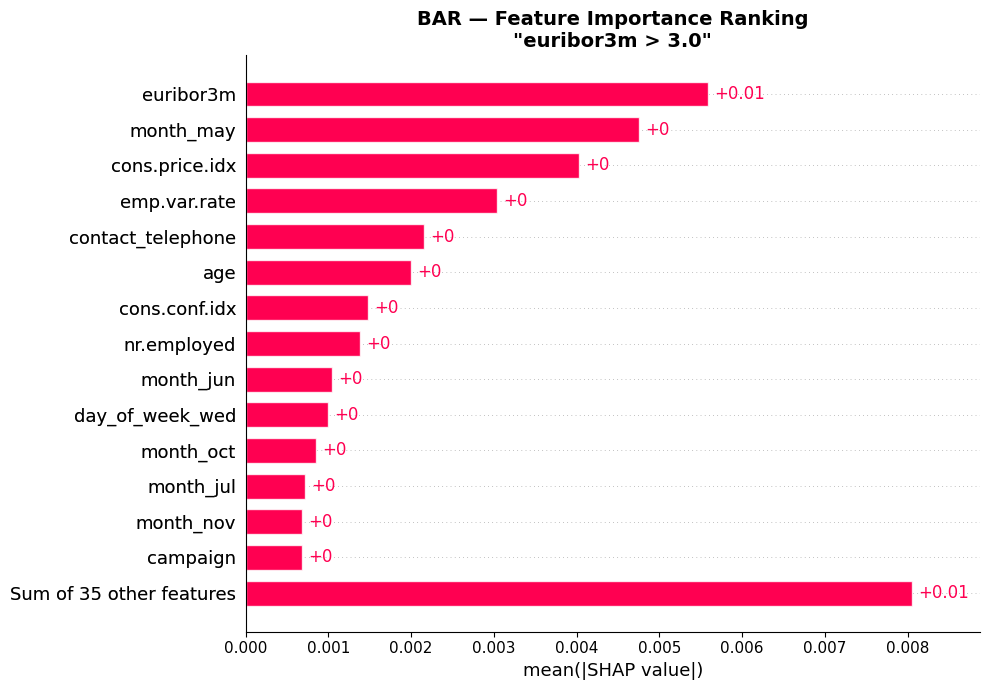

Saved → ../png/shap/euribor3m_gt_3.0_bar.png


In [25]:
# CELL 4B — SHAP BAR CHART
# Ranked magnitude, no direction
# Reuses sv, sname from Cell 4A — run that first

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.bar(sv, max_display=15, show=False, ax=ax)
ax.set_title(f'BAR — Feature Importance Ranking\n"{scenario}"',
              fontsize=14, fontweight='bold')
plt.tight_layout()
path = f'../png/shap/{sname}_bar.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

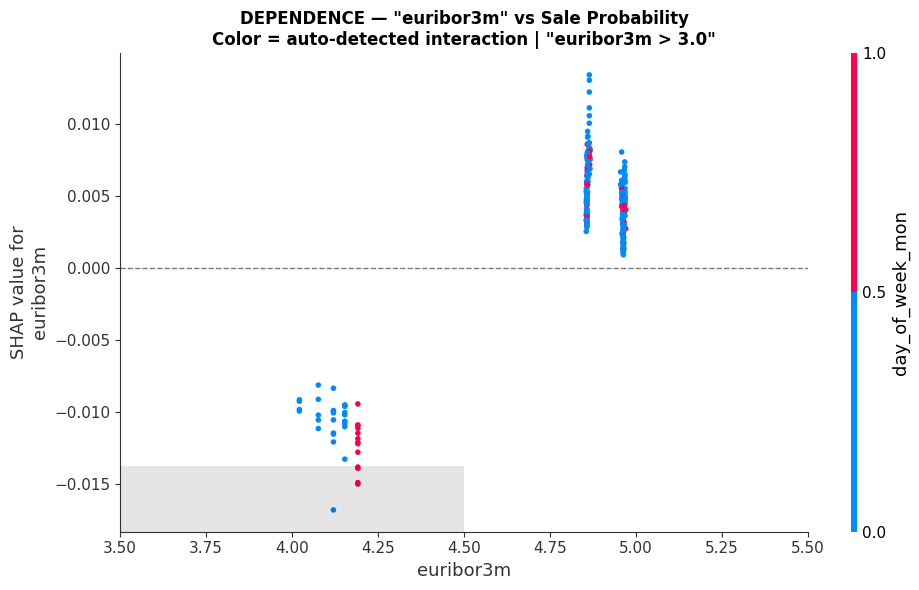

Saved → ../png/shap/euribor3m_gt_3.0_depend_euribor3m.png
HOW TO READ: Each dot = 1 customer. Above 0 = pushes toward sale. Below 0 = pushes away.
WHERE THE BEND IS = the threshold where this feature flips direction.


In [ ]:
# CELL 4C — DEPENDENCE PLOT ("ORANGE STYLE")
# ── Change this ──
feature = 'euribor3m'   # try: age, campaign, nr.employed, cons.price.idx_x
# ─────────────────
# Reuses sv, sname, scenario from Cell 4A

# X-axis = feature value
# Y-axis = SHAP impact on sale probability
# Color  = auto-detected interacting feature (the orange dots)
if feature in sv.feature_names:
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.scatter(sv[:, feature], color=sv, ax=ax, show=False)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # zero = neutral
    ax.set_title(
        f'DEPENDENCE — "{feature}" vs Sale Probability\n'
        f'Color = auto-detected interaction | "{scenario}"',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    path = f'../png/shap/{sname}_depend_{feature}.png'
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')
    print('HOW TO READ: Each dot = 1 customer. Above 0 = pushes toward sale. Below 0 = pushes away.')
    print('WHERE THE BEND IS = the threshold where this feature flips direction.')
else:
    print(f'Feature "{feature}" not found. Available numeric features:')
    print([f for f in sv.feature_names if 'euribor' in f or 'age' in f or 'campaign' in f or 'nr.' in f])

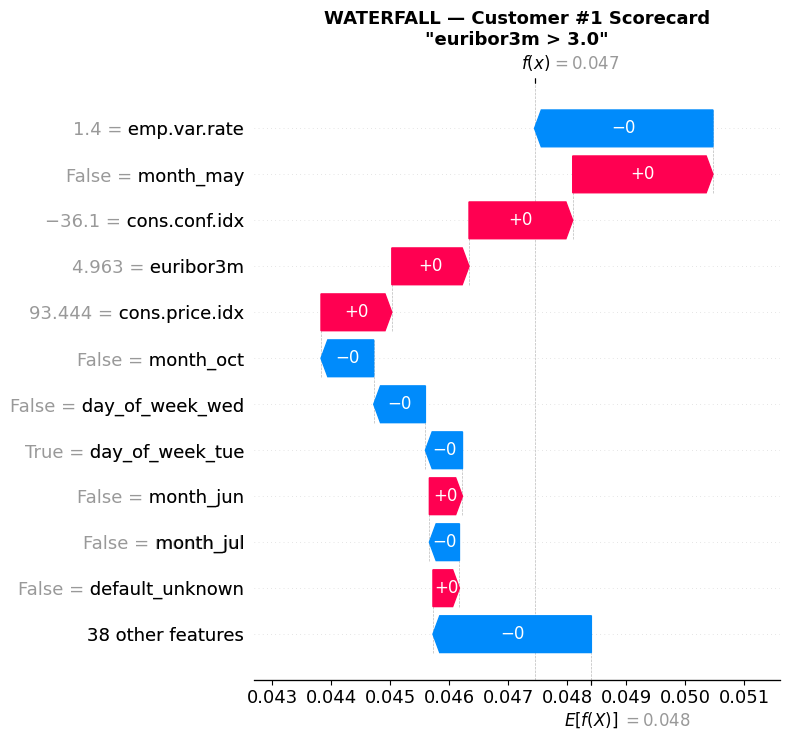

Saved → ../png/shap/euribor3m_gt_3.0_waterfall_cust1.png


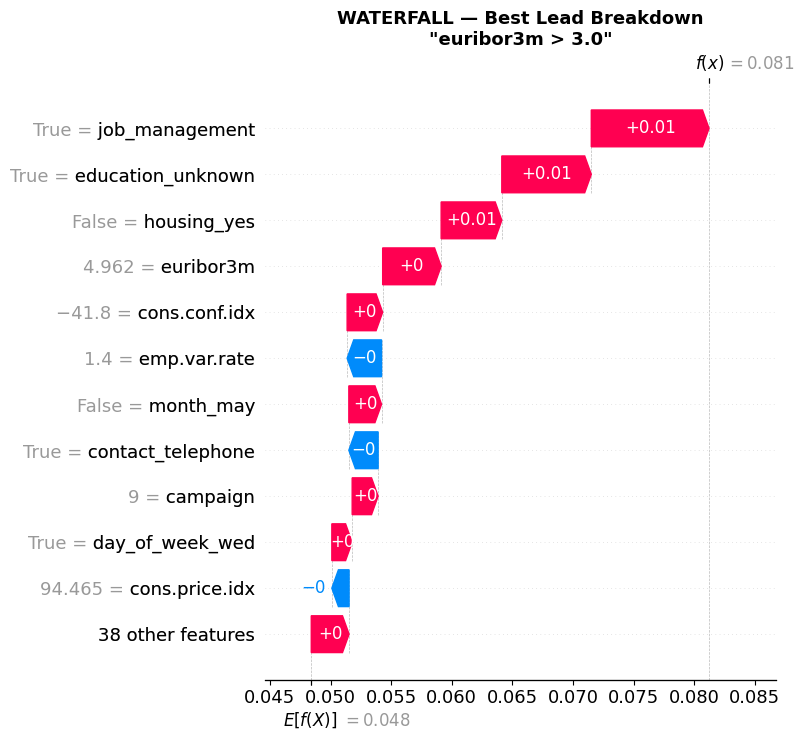

Saved → ../png/shap/euribor3m_gt_3.0_waterfall_bestlead.png


In [27]:
# CELL 4D — WATERFALL SCORECARD
# Reuses sv, sname, scenario, X_sample from Cell 4A

# ── Waterfall for customer #1 ─────────────────────────────────────────────
# Starting E[f(x)] = base rate; each row adds/subtracts toward final score
plt.figure(figsize=(11, 7))
shap.plots.waterfall(sv[0], max_display=12, show=False)
plt.title(f'WATERFALL — Customer #1 Scorecard\n"{scenario}"', fontsize=13, fontweight='bold')
plt.tight_layout()
path = f'../png/shap/{sname}_waterfall_cust1.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

# ── Waterfall for best lead ───────────────────────────────────────────────
# Most positive SHAP sum = model's highest-confidence target
best_idx = int(np.argmax(sv.values.sum(axis=1)))
plt.figure(figsize=(11, 7))
shap.plots.waterfall(sv[best_idx], max_display=12, show=False)
plt.title(f'WATERFALL — Best Lead Breakdown\n"{scenario}"', fontsize=13, fontweight='bold')
plt.tight_layout()
path = f'../png/shap/{sname}_waterfall_bestlead.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

  Done: Global Baseline (n=41,188)
  Done: High Rate (n=27,690)
  Done: Low Rate (n=13,216)
  Done: Retirees (n=1,720)
  Done: Students (n=875)
  Done: First Contact (n=17,642)
  Done: Contact Fatigue (n=7,635)
  Done: Warm Leads (n=1,515)


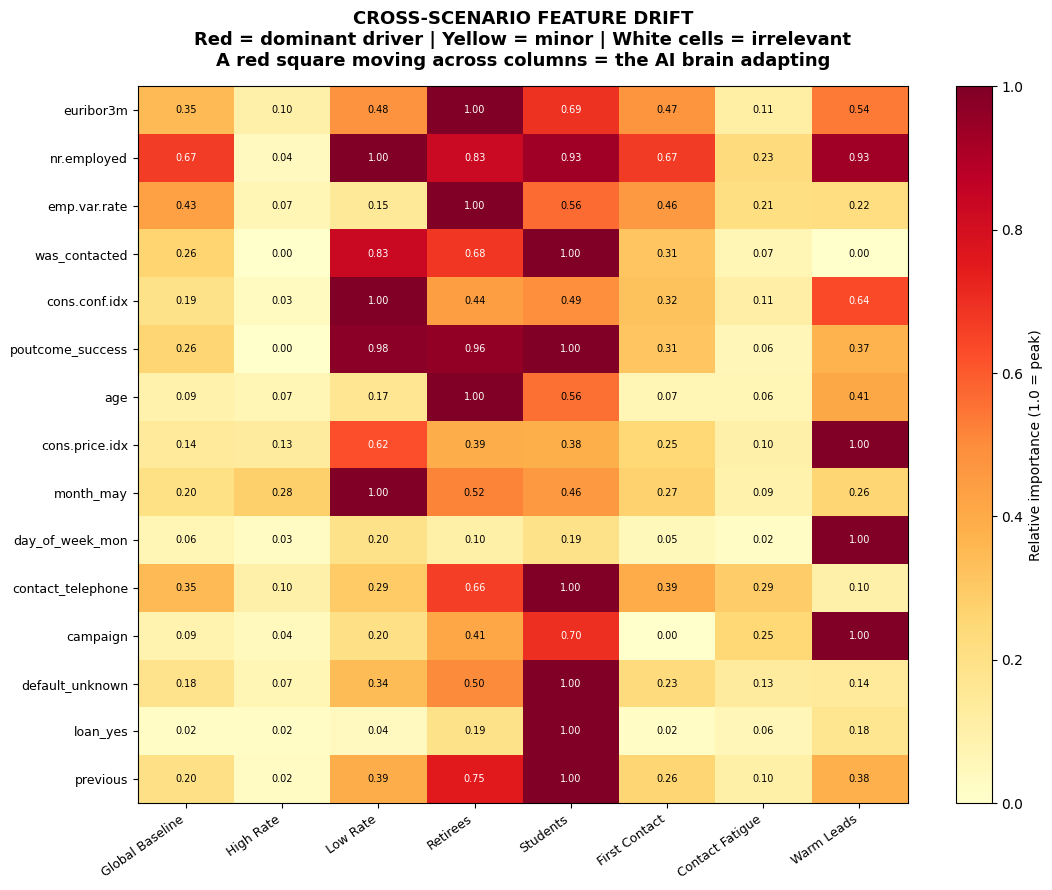

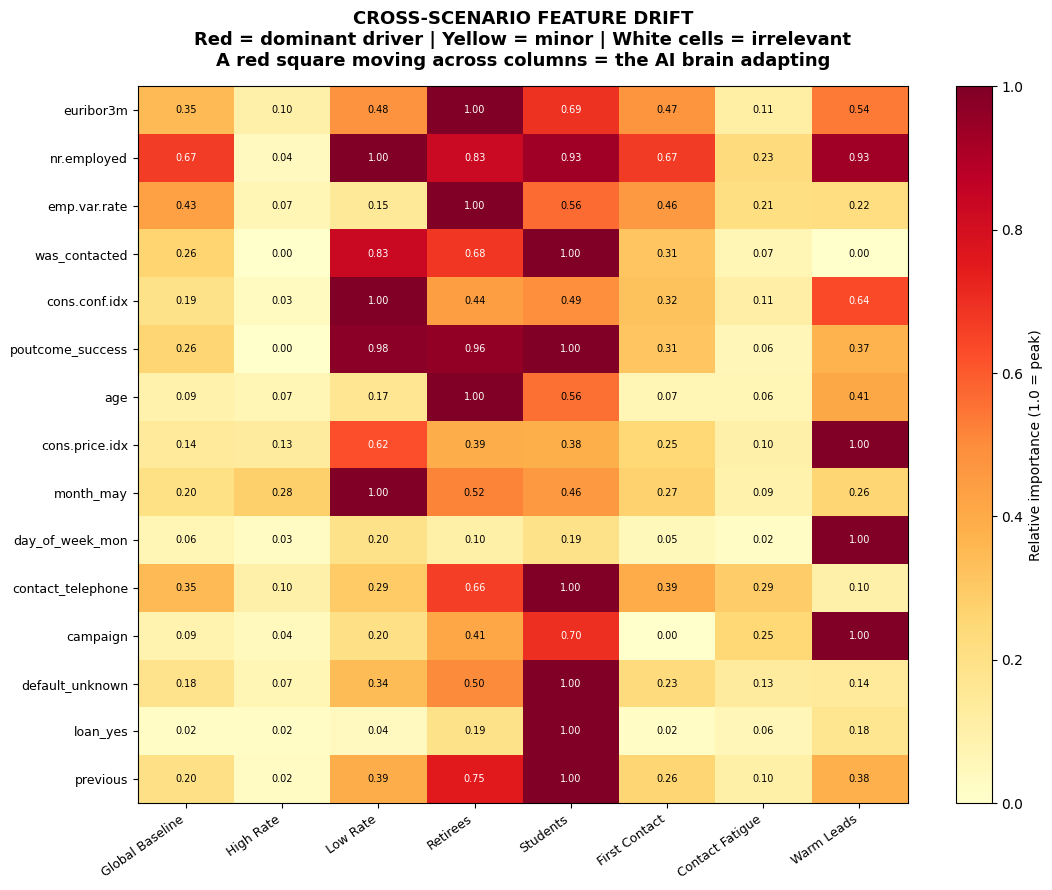

Saved → ../png/shap/cross_scenario_heatmap.png


In [29]:
# CELL 5 — CROSS-SCENARIO HEATMAP
# Run this AFTER changing Cell 4A multiple times.
# Manually build results dict — add each scenario you've run.

# ── Collect importances per scenario ─────────────────────────────────────
scenarios_to_compare = [
    ('Global Baseline',    None),
    ('High Rate',          'euribor3m > 3.0'),
    ('Low Rate',           'euribor3m < 1.5'),
    ('Retirees',           "job == 'retired'"),
    ('Students',           "job == 'student'"),
    ('First Contact',      'campaign == 1'),
    ('Contact Fatigue',    'campaign > 3'),
    ('Warm Leads',         'was_contacted == 1'),
]

all_importances = {}

for name, filt in scenarios_to_compare:
    work = df.query(filt).copy() if filt else df.copy()
    if len(work) < 200:
        print(f'  SKIP {name} — too small')
        continue
    X_ = pd.get_dummies(work.drop(['y', 'Persona'], axis=1), drop_first=True)
    y_ = work['y']
    m  = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42).fit(X_, y_)
    exp_ = shap.TreeExplainer(m)
    Xs   = X_.sample(min(200, len(X_)), random_state=42)
    raw_ = exp_.shap_values(Xs)
    mat_ = raw_[:, :, 1] if raw_.ndim == 3 else raw_[1]
    all_importances[name] = pd.Series(np.abs(mat_).mean(axis=0), index=Xs.columns)
    print(f'  Done: {name} (n={len(work):,})')

# ── Build heatmap ─────────────────────────────────────────────────────────
hmap = pd.DataFrame(all_importances).fillna(0)

# Top 15 features across all scenarios
top15  = hmap.max(axis=1).nlargest(15).index
hmap   = hmap.loc[top15]

# Normalize: 1.0 = most important in any scenario
hmap_n = hmap.div(hmap.max(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(max(10, len(all_importances) * 1.4), 9))
im = ax.imshow(hmap_n.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Relative importance (1.0 = peak)')

ax.set_xticks(range(len(hmap_n.columns)))
ax.set_xticklabels(hmap_n.columns, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(hmap_n.index)))
ax.set_yticklabels(hmap_n.index, fontsize=9)

# Cell labels
for i in range(len(hmap_n.index)):
    for j in range(len(hmap_n.columns)):
        v = hmap_n.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7, color='white' if v > 0.6 else 'black')

ax.set_title('CROSS-SCENARIO FEATURE DRIFT\n'
              'Red = dominant driver | Yellow = minor | White cells = irrelevant\n'
              'A red square moving across columns = the AI brain adapting',
              fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
path = '../png/shap/cross_scenario_heatmap.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

GBM trained for PDP...


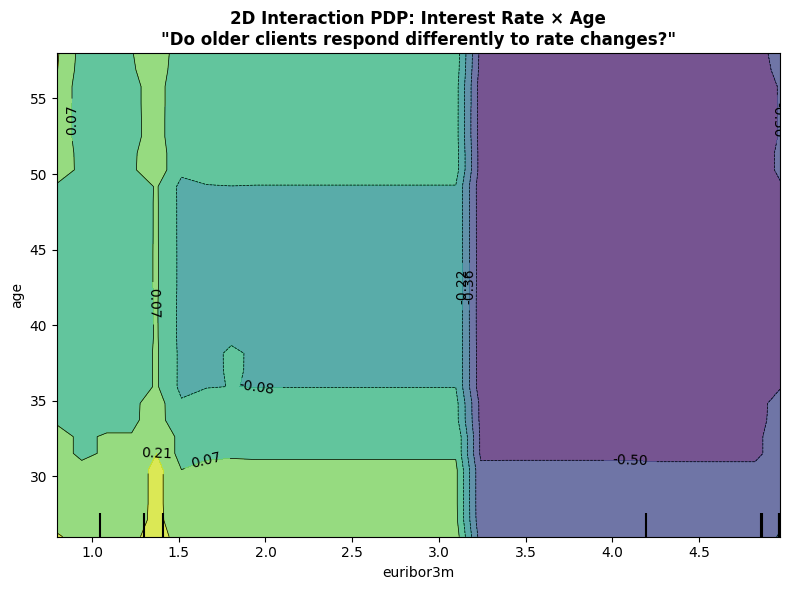

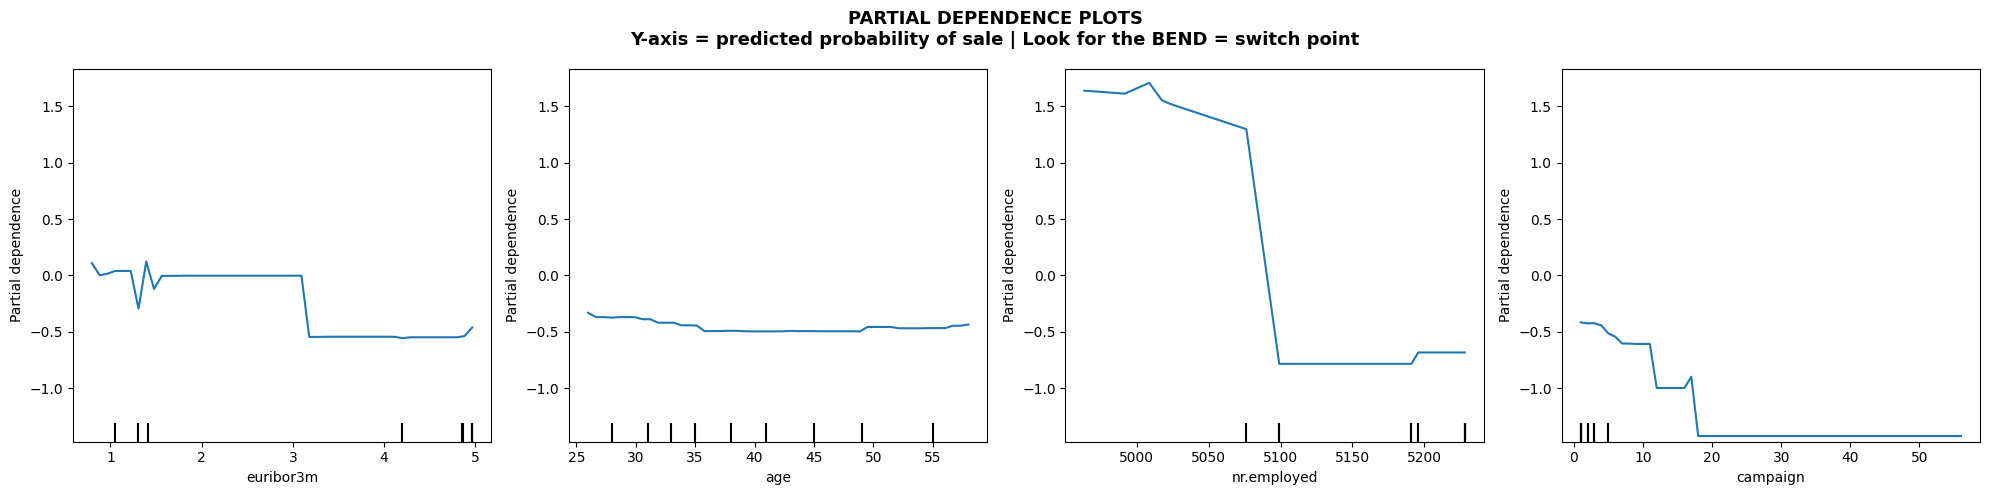

Saved → ../png/shap/pdp_macro.png


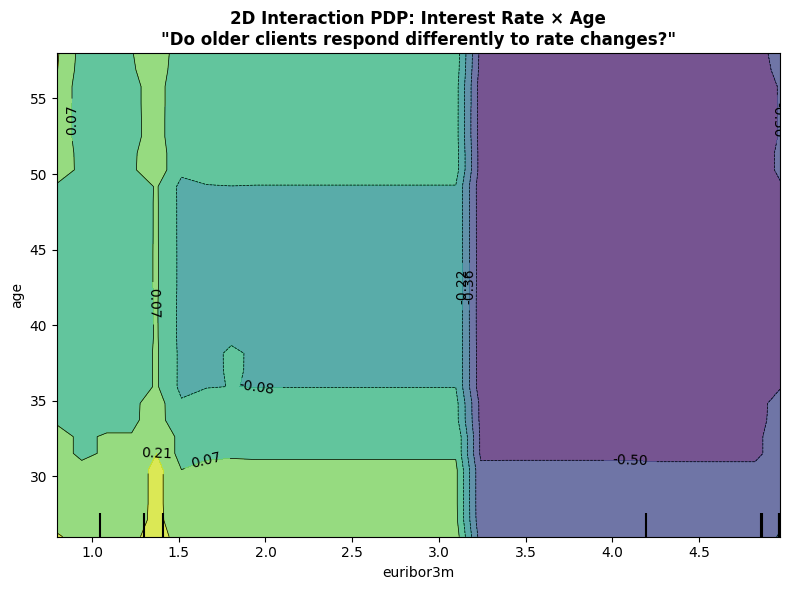

Saved → ../png/shap/pdp_euribor_x_age.png


In [32]:
# CELL 6 — PARTIAL DEPENDENCE PLOTS
# Average sale probability as ONE feature changes
# All other features held constant ("all else equal")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay

# GBM works better with PDP (sklearn native)
X_pdp = pd.get_dummies(df.drop(['y', 'Persona'], axis=1), drop_first=True)
y_pdp = df['y']

gb = GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                 learning_rate=0.1, random_state=42)
gb.fit(X_pdp, y_pdp)
print('GBM trained for PDP...')

# ── 4 macro features side-by-side ─────────────────────────────────────────
pdp_features = [f for f in ['euribor3m', 'age', 'nr.employed', 'campaign']
                if f in X_pdp.columns]

fig, axes = plt.subplots(1, len(pdp_features), figsize=(5 * len(pdp_features), 5))
if len(pdp_features) == 1: axes = [axes]

PartialDependenceDisplay.from_estimator(gb, X_pdp, pdp_features,
                                         ax=axes, kind='average', grid_resolution=50)
fig.suptitle('PARTIAL DEPENDENCE PLOTS\n'
              'Y-axis = predicted probability of sale | Look for the BEND = switch point',
              fontsize=13, fontweight='bold')
plt.tight_layout()
path = '../png/shap/pdp_macro.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

# ── 2D interaction: euribor × age ────────────────────────────────────────
if 'euribor3m' in X_pdp.columns and 'age' in X_pdp.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    PartialDependenceDisplay.from_estimator(gb, X_pdp, [('euribor3m', 'age')],
                                             ax=[ax], kind='average', grid_resolution=30)
    ax.set_title('2D Interaction PDP: Interest Rate × Age\n'
                  '"Do older clients respond differently to rate changes?"',
                  fontsize=12, fontweight='bold')
    plt.tight_layout()
    path = '../png/shap/pdp_euribor_x_age.png'
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')

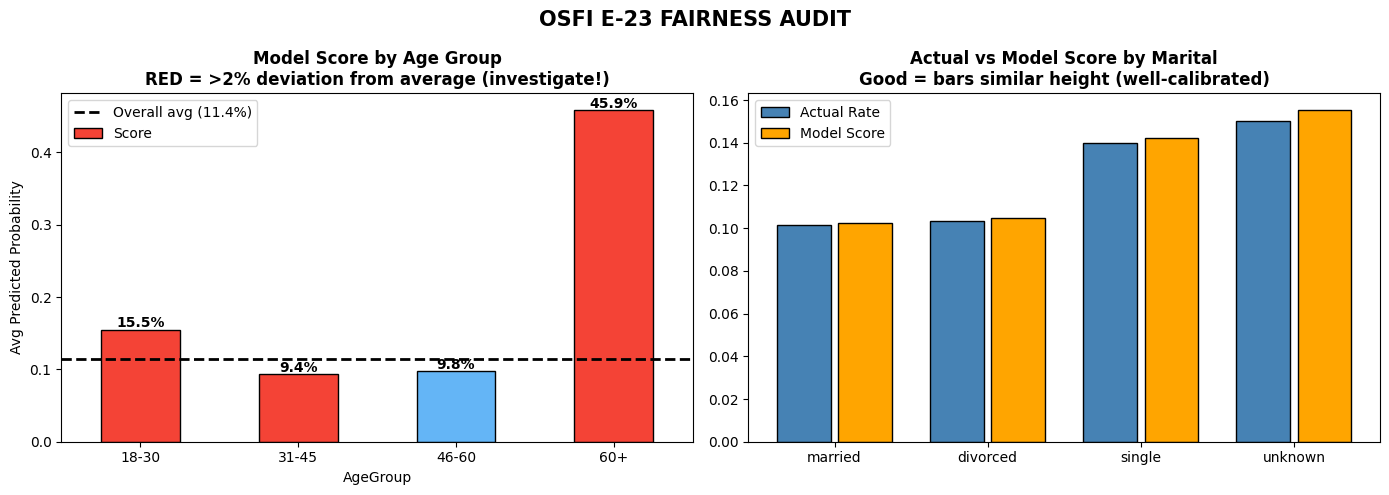

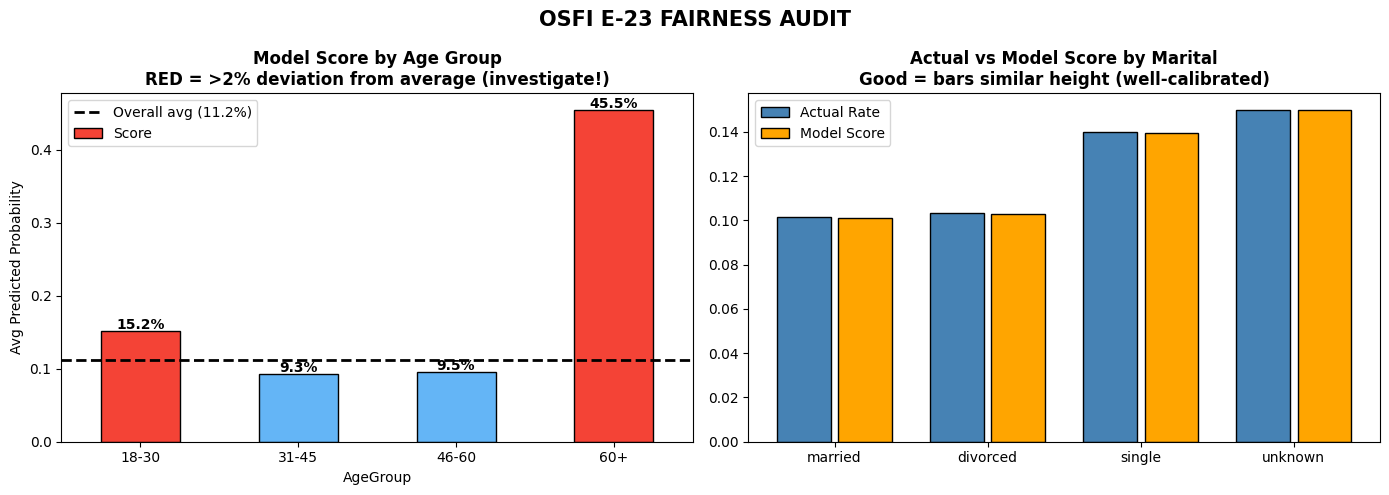

Saved → ../png/fairness/e23_audit.png

Fairness gaps:
  Age group range:     36.15%
  Marital status range: 4.87%
Under 5% difference = generally acceptable. Over 10% = escalate to risk.


In [34]:
# CELL 7 — FAIRNESS AUDIT (E-23)
# OSFI requires: no discrimination by age/marital
# Red flag = large gap between groups

# Train full model
X_fair = pd.get_dummies(df.drop(['y', 'Persona'], axis=1), drop_first=True)
model_fair = RandomForestClassifier(n_estimators=100, random_state=42)
model_fair.fit(X_fair, df['y'])
df['Score'] = model_fair.predict_proba(X_fair)[:, 1]

# ── Group scores by age band + marital ────────────────────────────────────
df['AgeGroup'] = pd.cut(df['age'], bins=[17, 30, 45, 60, 99],
                         labels=['18-30', '31-45', '46-60', '60+'])

age_scores     = df.groupby('AgeGroup', observed=True)['Score'].mean()
marital_scores = df.groupby('marital')['Score'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
overall    = df['Score'].mean()

# Age plot
age_colors = ['#F44336' if abs(v - overall) > 0.02 else '#64B5F6'   # red = flag
              for v in age_scores]
age_scores.plot(kind='bar', ax=axes[0], color=age_colors, edgecolor='black')
axes[0].axhline(overall, color='black', linestyle='--', linewidth=2,
                 label=f'Overall avg ({overall:.1%})')
axes[0].set_title('Model Score by Age Group\n'
                   'RED = >2% deviation from average (investigate!)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Predicted Probability'); axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(age_scores):
    axes[0].text(i, v + 0.003, f'{v:.1%}', ha='center', fontweight='bold')

# Marital plot — actual vs model
x = range(len(marital_scores))
actual = df.groupby('marital')['y'].mean().reindex(marital_scores.index)
axes[1].bar([i - 0.2 for i in x], actual, width=0.35,
             color='steelblue', label='Actual Rate', edgecolor='black')
axes[1].bar([i + 0.2 for i in x], marital_scores, width=0.35,
             color='orange', label='Model Score', edgecolor='black')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(marital_scores.index)
axes[1].set_title('Actual vs Model Score by Marital\n'
                   'Good = bars similar height (well-calibrated)',
                   fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('OSFI E-23 FAIRNESS AUDIT', fontsize=15, fontweight='bold')
plt.tight_layout()
path = '../png/fairness/e23_audit.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

print(f'\nFairness gaps:')
print(f'  Age group range:     {age_scores.max() - age_scores.min():.2%}')
print(f'  Marital status range: {marital_scores.max() - marital_scores.min():.2%}')
print('Under 5% difference = generally acceptable. Over 10% = escalate to risk.')

Call Cost: $5 | Sale Value: $300
                Count  ConvRate   Profit    ROI
Action                                         
CALL_NOW         4385     1.000  1293575  59.00
DO_NOT_CONTACT  36415     0.002  -162275  -0.89
EMAIL_ONLY          8     0.500     1160  29.00
NURTURE            74     0.568    12230  33.05
ONE_MORE_TRY      306     0.467    41370  27.04


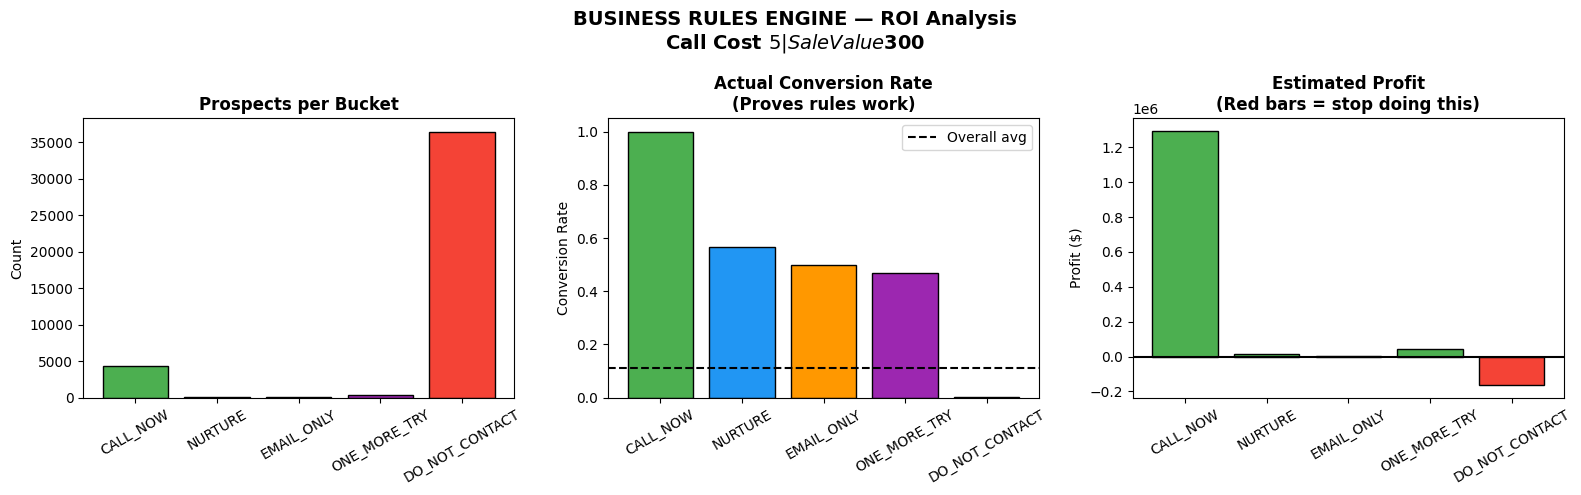

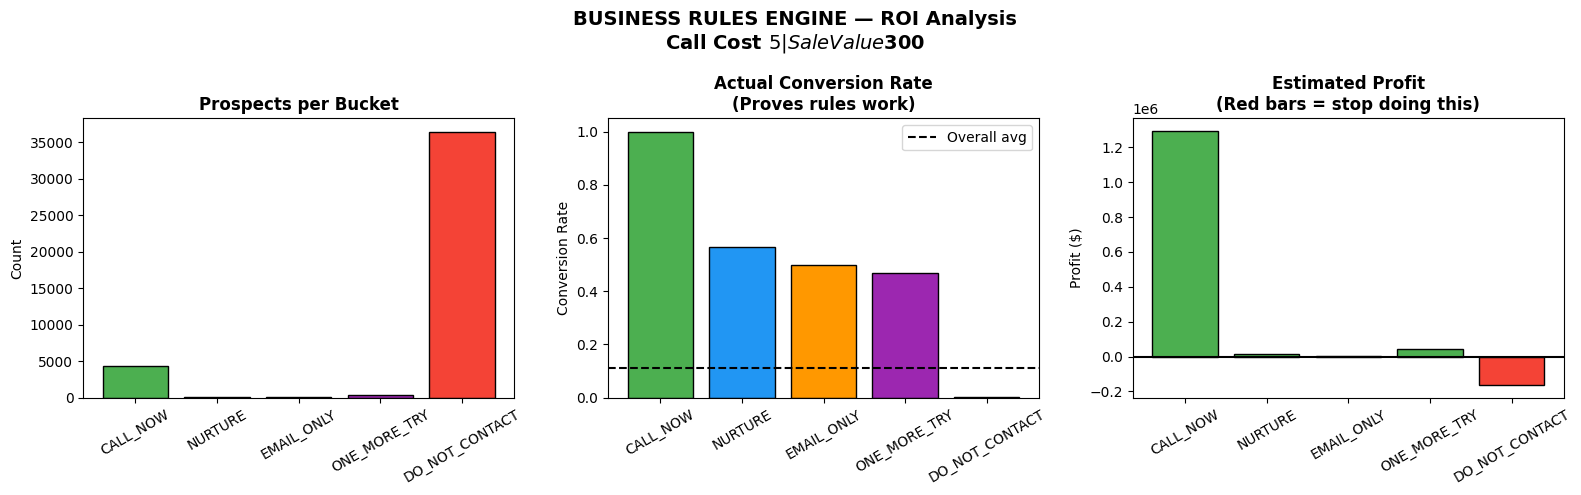

Saved → ../png/strategy/business_rules.png


FileNotFoundError: [Errno 2] No such file or directory: 'png/strategy/score_distribution.png'

In [ ]:
# CELL 8 — BUSINESS RULES ENGINE
# ── Change costs here ──
call_cost  = 5    # $ per call
sale_value = 300  # $ per subscription
# ───────────────────────

# Score already in df from Cell 7 — retrain fresh if not
if 'Score' not in df.columns:
    X_ = pd.get_dummies(df.drop(['y', 'Persona'], axis=1), drop_first=True)
    m  = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_, df['y'])
    df['Score'] = m.predict_proba(X_)[:, 1]

# ── Routing logic ─────────────────────────────────────────────────────────
def route(score, calls):
    if score >= 0.80:                  return 'CALL_NOW'          # hot lead
    if 0.55 <= score < 0.80 and calls <= 2: return 'NURTURE'      # warm, keep trying
    if 0.55 <= score < 0.80:           return 'EMAIL_ONLY'        # warm but tired
    if 0.30 <= score < 0.55 and calls == 1: return 'ONE_MORE_TRY' # cold first touch
    return 'DO_NOT_CONTACT'                                        # not worth it

df['Action'] = df.apply(lambda r: route(r['Score'], r['campaign']), axis=1)

# ── ROI math ──────────────────────────────────────────────────────────────
stats = df.groupby('Action').agg(Count=('y','count'), Conversions=('y','sum'), ConvRate=('y','mean'))
stats['Revenue'] = stats['Conversions'] * sale_value
stats['Cost']    = stats['Count'] * call_cost
stats['Profit']  = stats['Revenue'] - stats['Cost']
stats['ROI']     = (stats['Profit'] / stats['Cost']).round(2)

print(f'Call Cost: ${call_cost} | Sale Value: ${sale_value}')
print('=' * 55)
print(stats[['Count', 'ConvRate', 'Profit', 'ROI']].round(3))
print('=' * 55)

# ── Three panels ──────────────────────────────────────────────────────────
ORDER  = ['CALL_NOW', 'NURTURE', 'EMAIL_ONLY', 'ONE_MORE_TRY', 'DO_NOT_CONTACT']
COLORS = {'CALL_NOW': '#4CAF50', 'NURTURE': '#2196F3',
           'EMAIL_ONLY': '#FF9800', 'ONE_MORE_TRY': '#9C27B0', 'DO_NOT_CONTACT': '#F44336'}
plot_s = stats.reindex([a for a in ORDER if a in stats.index])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_c = [COLORS[a] for a in plot_s.index]

# Left: population
axes[0].bar(plot_s.index, plot_s['Count'], color=bar_c, edgecolor='black')
axes[0].set_title('Prospects per Bucket', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=30)

# Middle: conversion rate
axes[1].bar(plot_s.index, plot_s['ConvRate'], color=bar_c, edgecolor='black')
axes[1].axhline(df['y'].mean(), color='black', linestyle='--', label='Overall avg')
axes[1].set_title('Actual Conversion Rate\n(Proves rules work)', fontweight='bold')
axes[1].set_ylabel('Conversion Rate'); axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

# Right: profit (red = money losing)
profit_c = ['#4CAF50' if p > 0 else '#F44336' for p in plot_s['Profit']]
axes[2].bar(plot_s.index, plot_s['Profit'], color=profit_c, edgecolor='black')
axes[2].axhline(0, color='black', linewidth=1.5)
axes[2].set_title('Estimated Profit\n(Red bars = stop doing this)', fontweight='bold')
axes[2].set_ylabel('Profit ($)'); axes[2].tick_params(axis='x', rotation=30)

plt.suptitle(f'BUSINESS RULES ENGINE — ROI Analysis\n'
              f'Call Cost ${call_cost} | Sale Value ${sale_value}',
              fontsize=14, fontweight='bold')
plt.tight_layout()
path = '../png/strategy/business_rules.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

# ── Score distribution + thresholds ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 50)
ax.hist(df.loc[df['y']==0, 'Score'], bins=bins, alpha=0.6, color='#F44336', label='Not subscribed')
ax.hist(df.loc[df['y']==1, 'Score'], bins=bins, alpha=0.8, color='#4CAF50', label='Subscribed ✓')
ax.axvline(0.80, color='green',  linestyle='--', linewidth=2, label='CALL_NOW (≥0.80)')
ax.axvline(0.55, color='blue',   linestyle='--', linewidth=2, label='NURTURE  (0.55)')
ax.axvline(0.30, color='orange', linestyle='--', linewidth=2, label='ONE TRY  (0.30)')
ax.set_title('Score Distribution + Decision Thresholds\n'
              'Overlap zone = uncertain customers where rules matter most',
              fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Subscription Probability')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
path = '../png/strategy/score_distribution.png'
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')